In [1]:
%load_ext autoreload
%autoreload 2
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torchvision.datasets import ImageFolder
import os
from torch.utils.data import DataLoader, random_split, ConcatDataset, Dataset
from torch.utils.data import Subset 
import random
import pandas as pd
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import torch.optim as optim
import seaborn as sns
import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")




Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # [-1,1]
])
train_dataset = ImageFolder(
    root="data/afhq/train",
    transform=transform
)

test_dataset = ImageFolder(
    root="data/afhq/val",
    transform=transform
)
dog_idx = train_dataset.class_to_idx['cat']

# Filter indices for dog class only
train_dog_indices = [i for i, (_, label) in enumerate(train_dataset) if label == dog_idx]
test_dog_indices = [i for i, (_, label) in enumerate(test_dataset) if label == dog_idx]

train_dog = Subset(train_dataset, train_dog_indices)
test_dog = Subset(test_dataset, test_dog_indices)

full_dataset = ConcatDataset([train_dog, test_dog])

In [4]:
len(full_dataset)

5653

In [3]:
batch_size = 72
train_loader = DataLoader(full_dataset, batch_size= batch_size)

In [4]:
import math
class Flow(nn.Module):
    def __init__(self, img_channels=1, base_channels=64, time_dim=256):
        super().__init__()
        
        self.time_dim = time_dim
        self.input_proj = nn.Conv2d(img_channels, base_channels, 3, padding=1)
        
        self.enc1 = TimestepSequential(
            ResBlock(base_channels, base_channels, time_dim),
            ResBlock(base_channels, base_channels, time_dim),
        )
        self.down1 = nn.Conv2d(base_channels, base_channels*2, 3, stride=2, padding=1)
        
        self.enc2  = TimestepSequential(
            ResBlock(base_channels*2, base_channels*2, time_dim),
            ResBlock(base_channels*2, base_channels*2, time_dim),
        )
        self.down2 = nn.Conv2d(base_channels*2, base_channels*4, 3, stride=2, padding=1)
        
        self.enc3 = TimestepSequential(
            ResBlock(base_channels*4, base_channels*4, time_dim),
            ResBlock(base_channels*4, base_channels*4, time_dim),
        )
        self.down3 = nn.Conv2d(base_channels*4, base_channels*8, 3, stride=2, padding=1)
        
        self.bottleneck = nn.Sequential(
            ResBlock(base_channels*8, base_channels*8, time_dim),
            SelfAttention(base_channels*8),
            ResBlock(base_channels*8, base_channels*8, time_dim)
        )
        
        self.up3 = nn.ConvTranspose2d(base_channels*8, base_channels*4, 2, stride=2)
        self.dec3 = TimestepSequential(
            ResBlock(base_channels*8, base_channels*4, time_dim),
            ResBlock(base_channels*4, base_channels*4, time_dim),
        )
        
        self.up2 = nn.ConvTranspose2d(base_channels*4, base_channels*2, 2, stride=2)
        self.dec2 = TimestepSequential(
            ResBlock(base_channels*4, base_channels*2, time_dim),
            ResBlock(base_channels*2, base_channels*2, time_dim),
        )

        self.up1 = nn.ConvTranspose2d(base_channels*2, base_channels, 2, stride=2)
        self.dec1 = TimestepSequential(
            ResBlock(base_channels*2, base_channels, time_dim),
            ResBlock(base_channels, base_channels, time_dim),
        )
        
        self.output = nn.Sequential(
            nn.GroupNorm(8, base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, img_channels, 3, padding=1)
        )
    
    
    def get_time_embedding(self, t):
        half_dim = self.time_dim // 2
        emb = torch.log(torch.tensor(10000.0, device=t.device)) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb
    
    def forward(self, x, t):
        t_emb = self.get_time_embedding(t)
        x = self.input_proj(x)

        e1 = self.enc1(x, t_emb)
        x = self.down1(e1)
        
        e2 = self.enc2(x, t_emb)
        x = self.down2(e2)

        e3 = self.enc3(x, t_emb)
        x = self.down3(e3)

        # Bottleneck
        x = self.bottleneck[0](x, t_emb)
        x = self.bottleneck[1](x) 
        x = self.bottleneck[2](x, t_emb)
        
        x = self.up3(x)
        x = torch.cat([x, e3], dim=1)
        x = self.dec3(x, t_emb)
        x = self.up2(x)
        x = torch.cat([x, e2], dim=1)
        x = self.dec2(x, t_emb)
        
        x = self.up1(x)
        x = torch.cat([x, e1], dim=1)
        x = self.dec1(x, t_emb)
        
        return self.output(x)

class TimestepSequential(nn.Module):
    def __init__(self, *layers):
        super().__init__()
        self.layers = nn.ModuleList(layers)

    def forward(self, x, t_emb):
        for layer in self.layers:
            if isinstance(layer, ResBlock):
                x = layer(x, t_emb)
            else:
                x = layer(x)
        return x

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, out_ch)
        )
        
        self.block1 = nn.Sequential(
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv2d(in_ch, out_ch, 3, padding=1)
        )
        
        self.block2 = nn.Sequential(
            nn.GroupNorm(8, out_ch),
            nn.SiLU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1)
        )

        self.skip = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        
    def forward(self, x, t_emb=None):
        h = self.block1(x)
        if t_emb is not None:
            h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.block2(h)
        return (h + self.skip(x)) / math.sqrt(2)


class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        
    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W).permute(1, 0, 2, 3)
        q, k, v = qkv[0], qkv[1], qkv[2]
        
        attn = torch.softmax(torch.matmul(q.transpose(-2, -1), k) / (C ** 0.5), dim=-1)
        h = torch.matmul(v, attn.transpose(-2, -1)).reshape(B, C, H, W)
        
        return x + self.proj(h)

In [7]:
class Flow_light(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = nn.Sequential(
            nn.Conv2d(2, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU()
        )
        self.enc2 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU()
        )
        self.enc3 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.GroupNorm(32, 256), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.GroupNorm(32, 256), nn.ReLU()
        )
        
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1), nn.GroupNorm(32, 256), nn.ReLU()
        )
        
        self.dec3 = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1), nn.GroupNorm(32, 256), nn.ReLU(),
            nn.Conv2d(256, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU()
        )
        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1), nn.GroupNorm(16, 128), nn.ReLU(),
            nn.Conv2d(128, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU()
        )
        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1), nn.GroupNorm(8, 64), nn.ReLU(),
            nn.Conv2d(64, 1, 3, padding=1)
        )
        
        self.time_emb = nn.Sequential(
            nn.Linear(1, 256), nn.ReLU(),
            nn.Linear(256, 256)
        )
        
    def forward(self, x, t):
        t_emb = self.time_emb(t.view(-1, 1)).view(-1, 256, 1, 1)
        
        x = torch.cat([x, t.view(-1, 1, 1, 1).expand(-1, 1, 64, 64)], dim=1)
        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        
        b = self.bottleneck(e3 + t_emb)
        
        d3 = self.dec3(b)
        d3 = nn.functional.interpolate(d3, scale_factor=2, mode='bilinear', align_corners=False)
        d2 = self.dec2(torch.cat([d3, e2], dim=1))
        d2 = nn.functional.interpolate(d2, scale_factor=2, mode='bilinear', align_corners=False)
        d1 = self.dec1(torch.cat([d2, e1], dim=1))
        return d1

In [6]:
num_epochs = 100
model = Flow().to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = torch.cuda.amp.GradScaler()
loss_fn = nn.MSELoss()
sigma_m = 1e-5
eps = 1e-5

best_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for i, (images, _) in enumerate(pbar):
        images = images.to(device, non_blocking=True).float()
        
        noise = torch.randn_like(images)
        t = torch.rand(images.size(0), device=device).clamp(eps, 1 - eps)
        
        t_view = t.view(-1, 1, 1, 1)
        x_t = (1 - (1 - sigma_m) * t_view) * noise + t_view * images
        u_true = images - noise
        
        with torch.amp.autocast('cuda'):
            outputs = model(x_t, t)
            loss = loss_fn(outputs, u_true)
        
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{running_loss/(i+1):.4f}', 'lr': f'{scheduler.get_last_lr()[0]:.2e}'})
    
    scheduler.step()
    
    if running_loss/(i+1) < best_loss:
        best_loss = running_loss/(i+1)
        torch.save(model.state_dict(), 'best_flow_model.pt')

C:\Users\anhqu\AppData\Local\Temp\ipykernel_12216\3278528466.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
Epoch 100/100: 100%|██████████| 79/79 [00:36<00:00,  2.19it/s, loss=0.1819, lr=2.47e-08]


In [7]:
import numpy as np
image_size = full_dataset[0][0].shape[1]
steps = 200
print("\nGenerating samples...")
model.eval()

with torch.no_grad():
    x_0 = torch.randn(16, 1, image_size, image_size, device=device)
    T = np.linspace(0, 1, steps)
    x_t = x_0
    
    pbar = tqdm.tqdm(range(steps-1), desc="Sampling")
    for step in pbar:
        t_start = torch.tensor(T[step], dtype=torch.float32).expand(16).to(device)
        t_end = torch.tensor(T[step+1], dtype=torch.float32).expand(16).to(device)
        dt = (t_end - t_start).view(-1, 1, 1, 1)

        x_mid = x_t + model(x_t, t_start) * (dt / 2)
        x_t = x_t + dt * model(x_mid, t_start + (t_end - t_start) / 2)
    
    samples = x_t.cpu()


Generating samples...


Sampling: 100%|██████████| 199/199 [00:13<00:00, 14.91it/s]


In [8]:
def inverse_transform(tensor):
    if isinstance(tensor, np.ndarray):
        tensor = tensor * 0.5 + 0.5
        tensor = np.clip(tensor, 0, 1)
    else:
        tensor = tensor * 0.5 + 0.5
        tensor = torch.clamp(tensor, 0, 1)
    return tensor

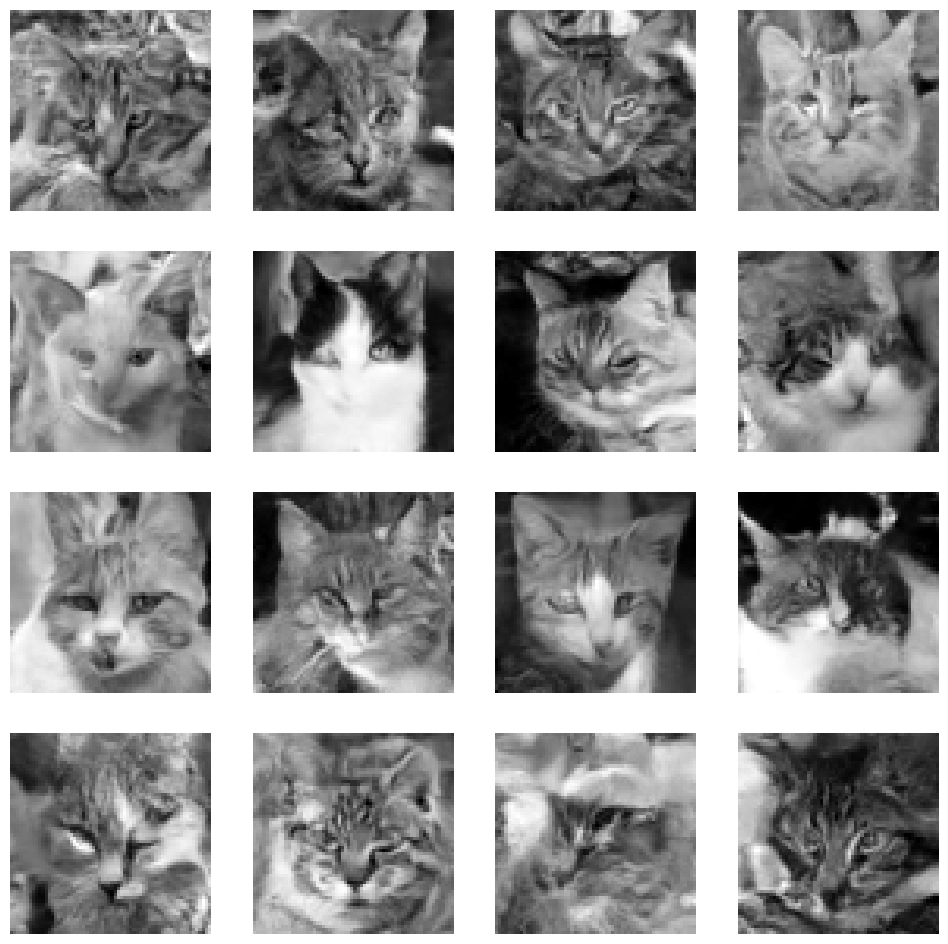

In [9]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img = inverse_transform(samples[i]).squeeze().cpu().numpy()
    ax.imshow(img, cmap='gray')
    ax.axis('off')

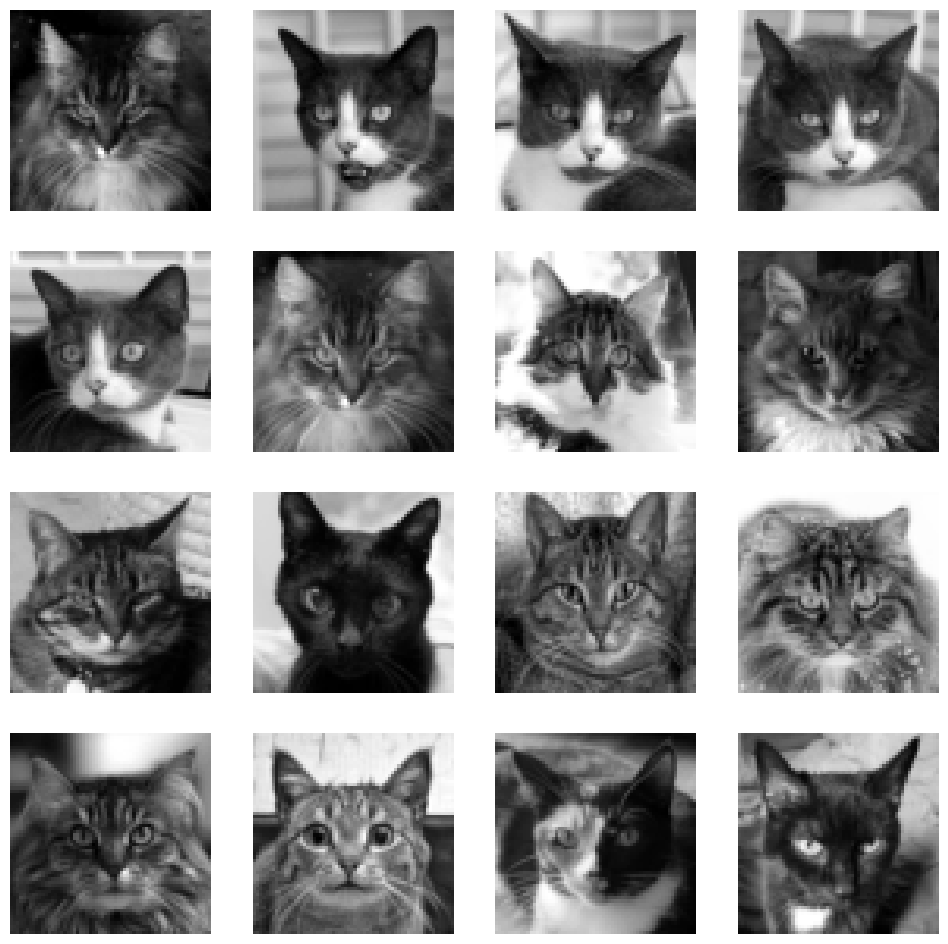

In [64]:
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img = inverse_transform(full_dataset[i][0]).squeeze().cpu().numpy()
    ax.imshow(img, cmap='gray')
    ax.axis('off')


Generating sample with visualization...


Sampling: 100%|██████████| 999/999 [00:25<00:00, 39.76it/s]


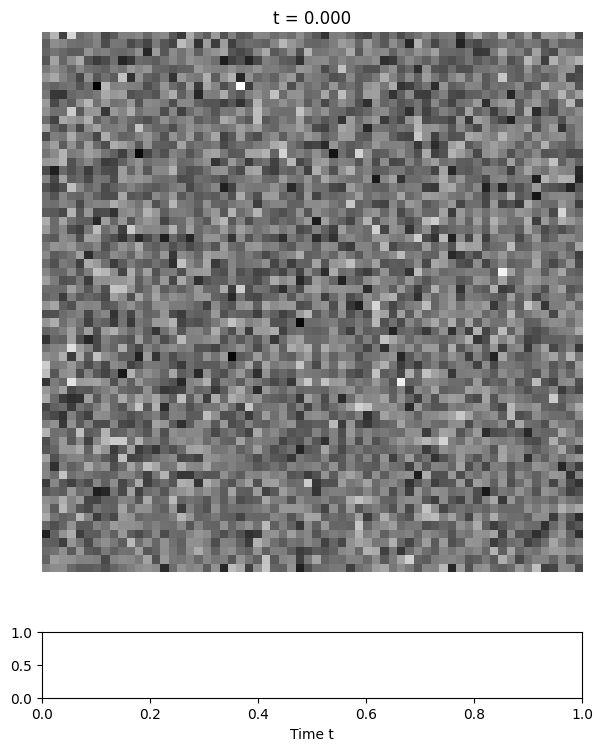

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

image_size = full_dataset[0][0].shape[1]
steps = 1000
save_every = steps // 20

print("\nGenerating sample with visualization...")
model.eval()

frames = []
time_steps = []

with torch.no_grad():
    x_0 = torch.randn(1, 1, image_size, image_size, device=device)
    T = np.linspace(0, 1, steps)
    x_t = x_0
    
    pbar = tqdm.tqdm(range(steps-1), desc="Sampling")
    for step in pbar:
        if step % save_every == 0:
            frames.append(x_t.cpu().squeeze().numpy())
            time_steps.append(T[step])
        
        t_start = torch.tensor(T[step], dtype=torch.float32).expand(1).to(device)
        t_end = torch.tensor(T[step+1], dtype=torch.float32).expand(1).to(device)
        dt = (t_end - t_start).view(-1, 1, 1, 1)

        x_mid = x_t + model(x_t, t_start) * (dt / 2)
        x_t = x_t + dt * model(x_mid, t_start + (t_end - t_start) / 2)
    
    frames.append(x_t.cpu().squeeze().numpy())
    time_steps.append(T[-1])

# Animate with time bar
fig, (ax_img, ax_bar) = plt.subplots(2, 1, figsize=(6, 8), 
                                      gridspec_kw={'height_ratios': [10, 1]})

im = ax_img.imshow(frames[0], cmap='gray')
ax_img.axis('off')

ax_bar.set_xlim(0, 1)
ax_bar.set_ylim(0, 1)
ax_bar.set_xlabel('Time t')
bar_fill = ax_bar.barh(0.5, 0, height=0.5, color='blue')

def update(frame_idx):
    im.set_array(frames[frame_idx])
    ax_img.set_title(f't = {time_steps[frame_idx]:.3f}')
    bar_fill[0].set_width(time_steps[frame_idx])

ani = FuncAnimation(fig, update, frames=len(frames), interval=200)
plt.tight_layout()
HTML(ani.to_jshtml())

In [12]:
torch.save(model.state_dict(), 'best_results/final_flow_model.pt')

In [22]:
from matplotlib.animation import PillowWriter

writer = PillowWriter(fps=5)
ani.save('sampling_process_1.gif', writer=writer, dpi=100)